###Pandas 함수

1. 위치 데이터의 부재(NaN): 화면에 출력된 상위 5개 행의 기점위도, 기점경도 등이 모두 NaN(결측치)입니다.
해결책: 주소(기점지번주소, 종점지번주소)는 있으므로, 나중에 카카오맵 API의 Geocoding(주소->좌표 변환) 기능을 사용해 빈 값을 채우는 로직을 백엔드에 구현해야 합니다. (이게 아주 좋은 포트폴리오 포인트입니다!)

2. 핵심 피처(Feature): 자전거도로너비(m), 자전거도로종류, 총길이(km)는 자전거의 주행 쾌적도와 안전 점수를 계산할 때 머신러닝 모델의 입력값으로 쓰기 딱 좋습니다.


안전 점수(Safety Score) 계산:
자전거도로종류가 '자전거 전용도로'이면 +20점, '보행자 겸용'이면 +10점.
자전거도로너비가 2m 이상이면 +15점.
여기에 아까 받은 사고 다발지 데이터를 매칭시켜서, 사고가 많은 지역은 -50점.
결과: 사용자에게 **"가장 안전하고 쾌적한 핑크색 경로"**를 추천합니다.
수익 모델(K-Ride):
주요경유지 컬럼에 '관광지'나 '유명 상권' 키워드가 있는지 검사합니다.
해당 경로를 이용하는 사용자에게만 주변 제휴 카페의 **'전기 자전거 충전 무료 쿠폰'**을 발행합니다.

In [1]:
import os

# 1. 현재 주피터 노트북의 실행 위치 확인
print(f"현재 위치: {os.getcwd()}")

# 2. 현재 폴더에 무엇이 있는지 확인
print(f"현재 폴더 내용: {os.listdir('.')}")

# 3. 상위 폴더나 하위 폴더에 raw_ml이 있는지 확인
possible_paths = [
    '../raw_ml/전국자전거도로표준데이터.csv',
    './raw_ml/전국자전거도로표준데이터.csv',
    './data/raw_ml/전국자전거도로표준데이터.csv'
]

for path in possible_paths:
    if os.path.exists(path):
        print(f"✅ 파일을 찾았습니다! 사용할 경로: {path}")
        break
else:
    print("❌ 파일을 찾지 못했습니다. 폴더 구조를 다시 확인해야 합니다.")

현재 위치: c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\kride-project
현재 폴더 내용: ['0330_taas_data.ipynb', '0331_taas_data..ipynb', 'data', 'db_schema.sql', 'docker-compose.yml', 'ml-server']
✅ 파일을 찾았습니다! 사용할 경로: ./data/raw_ml/전국자전거도로표준데이터.csv


In [11]:
import pandas as pd
import os
 
raw_file_path = './data/raw_ml/전국자전거도로표준데이터.csv'

try:
    # 인코딩 시도 (cp949 또는 utf-8)
    df = pd.read_csv(raw_file_path, encoding='cp949')
except:
    df = pd.read_csv(raw_file_path, encoding='utf-8')

print(f"원본 데이터 로드 완료: {len(df)}건")

# 2. 데이터 필터링 (df_clean 정의)
# 기점위도, 기점경도, 종점위도, 종점경도가 모두 있는 행만 추출
df_clean = df.dropna(subset=['기점위도', '기점경도', '종점위도', '종점경도']).copy()

# 숫자형으로 변환 (에러 발생 시 NaN 처리 후 다시 제거)
cols = ['기점위도', '기점경도', '종점위도', '종점경도', '자전거도로너비(m)']
for col in cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

df_clean = df_clean.dropna(subset=['기점위도', '기점경도', '종점위도', '종점경도'])

print(f"필터링 완료 (df_clean 생성됨): {len(df_clean)}건")

# 3. 저장 설정
target_dir = '../raw_ml'
file_name = 'bicycle_routes_clean.csv'
save_path = os.path.join(target_dir, file_name)

# 폴더 생성
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# 4. 파일 저장
try:
    df_clean.to_csv(save_path, index=False, encoding='utf-8-sig')
    print(f"✅ 성공! 파일이 저장되었습니다: {save_path}")
except Exception as e:
    print(f"❌ 저장 중 오류 발생: {e}")
    
# 상위 5개 행 및 컬럼명 확인
print(df.columns)
print(df.head())

원본 데이터 로드 완료: 20262건
필터링 완료 (df_clean 생성됨): 11771건
✅ 성공! 파일이 저장되었습니다: ../raw_ml\bicycle_routes_clean.csv
Index(['노선명', '노선번호', '시도명', '시군구명', '기점도로명주소', '기점지번주소', '종점도로명주소', '종점지번주소',
       '기점위도', '기점경도', '종점위도', '종점경도', '주요경유지', '총길이(km)', '일반도로너비(m)',
       '자전거도로너비(m)', '자전거도로종류', '자전거도로고시유무', '관리기관명', '관리기관전화번호', '데이터기준일자',
       '제공기관코드', '제공기관명'],
      dtype='str')
       노선명 노선번호  시도명 시군구명 기점도로명주소                 기점지번주소 종점도로명주소  \
0  사임당로(2)  NaN  경기도  파주시     NaN  경기도 파주시 문산읍 선유리 668-3     NaN   
1  사임당로(1)  NaN  경기도  파주시     NaN   경기도 파주시 문산읍 선유리 1358     NaN   
2     별하람로  NaN  경기도  파주시     NaN        경기도 파주시 와동동 802     NaN   
3      법흥로  NaN  경기도  파주시     NaN   경기도 파주시 탄현면 법흥리 1759     NaN   
4     범벅들길  NaN  경기도  파주시     NaN       경기도 파주시 다율동 1024     NaN   

                   종점지번주소  기점위도  기점경도  ...  총길이(km)  일반도로너비(m) 자전거도로너비(m)  \
0   경기도 파주시 문산읍 선유리 434-9   NaN   NaN  ...     2.32        NaN          2   
1  경기도 파주시 문산읍 선유리 772-25   NaN   NaN  ...     0.25       

In [12]:
# 첫 번째 행 선택 (인덱스 0)
first_row = df.iloc[0]
print(first_row)

# 두 번째 열 선택  
# iloc[행.열]
# iloc의 i는 index를 뜻한다 
age_column = df.iloc[:, 1]
print(age_column)

# 첫 번째 행부터 두 번째 행까지, 모든 열 선택
subset = df.iloc[0:2, :]
print(subset)

노선명                         사임당로(2)
노선번호                            NaN
시도명                             경기도
시군구명                            파주시
기점도로명주소                         NaN
기점지번주소        경기도 파주시 문산읍 선유리 668-3
종점도로명주소                         NaN
종점지번주소        경기도 파주시 문산읍 선유리 434-9
기점위도                            NaN
기점경도                            NaN
종점위도                            NaN
종점경도                            NaN
주요경유지                           NaN
총길이(km)                        2.32
일반도로너비(m)                       NaN
자전거도로너비(m)                        2
자전거도로종류                         NaN
자전거도로고시유무                       NaN
관리기관명                      경기도 파주시청
관리기관전화번호               031-940-4666
데이터기준일자                  2025-12-22
제공기관코드                      4060000
제공기관명                       경기도 파주시
Name: 0, dtype: object
0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
20257    NaN
20258    NaN
20259    NaN
20260    NaN
20261    NaN
Name: 

In [6]:
# '노선명' 열 선택
name_column = df.loc[:, '노선명']
print(name_column)



0         사임당로(2)
1         사임당로(1)
2            별하람로
3             법흥로
4            범벅들길
           ...   
20257       계동로2L
20258       계동로1R
20259       계동로1L
20260    서김해산단안길R
20261    서김해산단안길L
Name: 노선명, Length: 20262, dtype: str


 머신러닝 모델링 아이디어 (추천 엔진용)
이 데이터를 입력값(Feature)으로 하여 **'사용자 맞춤형 경로 추천 점수'**를 계산하는 모델을 구상해 보세요.
입력(Feature): road_width_m, route_type, total_length_km
가중치(Weight):
너비가 넓을수록 점수 UP
전용도로일수록 점수 UP
(나중에 합칠) 사고 다발지 정보가 겹치면 점수 DOWN
출력(Output): 해당 구간의 'Safety Index (1~100)'

In [13]:

# 결측치 확인: 전체 데이터 중 기점위도가 비어있는 행이 몇 개인지 확인
selected_rows = df.loc[df['기점위도'].isnull().sum()]
print(selected_rows)

노선명                     해마루공원로1R-32
노선번호                            NaN
시도명                            경상북도
시군구명                            구미시
기점도로명주소       경상북도 구미시 산동읍 신당리 1375
기점지번주소                          NaN
종점도로명주소           경상북도 구미시 구포동 1075
종점지번주소                          NaN
기점위도                      36.154061
기점경도                     128.434761
종점위도                      36.135557
종점경도                     128.428661
주요경유지                           NaN
총길이(km)                        0.05
일반도로너비(m)                       NaN
자전거도로너비(m)                      4.5
자전거도로종류                  자전거보행자겸용도로
자전거도로고시유무                         N
관리기관명                     경상북도 구미시청
관리기관전화번호               054-480-5485
데이터기준일자                  2025-02-20
제공기관코드                      5080000
제공기관명                      경상북도 구미시
Name: 8423, dtype: object


In [14]:
# 1. 위도/경도가 모두 있는 행만 추출
gps_exists = df.dropna(subset=['기점위도', '기점경도', '종점위도', '종점경도'])

# 2. 위도/경도는 없지만 주소라도 있는 행 추출 (나중에 API로 변환 가능)
address_only = df[df['기점위도'].isnull() & df['기점지번주소'].notnull()]

print(f"1. 즉시 지도에 표시 가능한 데이터: {len(gps_exists)}건")
print(f"2. 주소 변환이 필요한 데이터: {len(address_only)}건")
print(f"3. 정보가 부족해 버려야 할 데이터: {len(df) - len(gps_exists) - len(address_only)}건")

1. 즉시 지도에 표시 가능한 데이터: 11771건
2. 주소 변환이 필요한 데이터: 2514건
3. 정보가 부족해 버려야 할 데이터: 5977건


In [15]:
from itables import show
show(df)

Loading ITables v2.7.3 from the internet... (need help?)



# 모든 컬럼이 다 보이게 설정
pd.set_option('display.max_columns', None)

# 컬럼 너비를 제한 없이 설정
pd.set_option('display.max_colwidth', None)

# 소수점 둘레 설정
pd.set_option('display.precision', 2)

In [16]:
# 사전설치 : pip install pandas matplotlib seaborn
# python -m pip install --upgrade pip
# sudo pip install seaborn  # Mac/Linux
import pandas as pd
import matplotlib.pyplot as plt
import platform
import seaborn as sns

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')

plt.rcParams['axes.unicode_minus'] = False
 

In [17]:
df.head()    # 앞에서 5개 항목 출력   cf. tail() : 뒤에서 5개 항목

,노선명,노선번호,시도명,시군구명,기점도로명주소,기점지번주소,종점도로명주소,종점지번주소,기점위도,기점경도,...,총길이(km),일반도로너비(m),자전거도로너비(m),자전거도로종류,자전거도로고시유무,관리기관명,관리기관전화번호,데이터기준일자,제공기관코드,제공기관명
0,사임당로(2),NaN,경기도,파주시,NaN,경기도 파주시 문산읍 선유리 668-3,NaN,경기도 파주시 문산읍 선유리 434-9,NaN,NaN,...,2.32,NaN,2,NaN,NaN,경기도 파주시청,031-940-4666,2025-12-22,4060000,경기도 파주시
1,사임당로(1),NaN,경기도,파주시,NaN,경기도 파주시 문산읍 선유리 1358,NaN,경기도 파주시 문산읍 선유리 772-25,NaN,NaN,...,0.25,NaN,1.5,NaN,NaN,경기도 파주시청,031-940-4666,2025-12-22,4060000,경기도 파주시
2,별하람로,NaN,경기도,파주시,NaN,경기도 파주시 와동동 802,NaN,경기도 파주시 와동동 1664-390,NaN,NaN,...,0.83,NaN,1.5,NaN,NaN,경기도 파주시청,031-940-4666,2025-12-22,4060000,경기도 파주시
3,법흥로,NaN,경기도,파주시,NaN,경기도 파주시 탄현면 법흥리 1759,NaN,경기도 파주시 탄현면 법흥리 1678,NaN,NaN,...,1.28,NaN,1.8,NaN,NaN,경기도 파주시청,031-940-4666,2025-12-22,4060000,경기도 파주시
4,범벅들길,NaN,경기도,파주시,NaN,경기도 파주시 다율동 1024,NaN,경기도 파주시 다율동 794,NaN,NaN,...,1.08,NaN,1.5,NaN,NaN,경기도 파주시청,031-940-4666,2025-12-22,4060000,경기도 파주시


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20262 entries, 0 to 20261
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   노선명         20262 non-null  str    
 1   노선번호        3145 non-null   str    
 2   시도명         20262 non-null  str    
 3   시군구명        20262 non-null  str    
 4   기점도로명주소     16476 non-null  str    
 5   기점지번주소      4265 non-null   str    
 6   종점도로명주소     16498 non-null  str    
 7   종점지번주소      4260 non-null   str    
 8   기점위도        11839 non-null  float64
 9   기점경도        11839 non-null  float64
 10  종점위도        11810 non-null  float64
 11  종점경도        11810 non-null  float64
 12  주요경유지       2524 non-null   str    
 13  총길이(km)     20262 non-null  float64
 14  일반도로너비(m)   1420 non-null   float64
 15  자전거도로너비(m)  20262 non-null  str    
 16  자전거도로종류     16894 non-null  str    
 17  자전거도로고시유무   15921 non-null  str    
 18  관리기관명       19923 non-null  str    
 19  관리기관전화번호    17974 non-null  str    


In [19]:
df.describe()

,기점위도,기점경도,종점위도,종점경도,총길이(km),일반도로너비(m),제공기관코드
count,11839.000000,11839.000000,11810.000000,11810.000000,20262.000000,1420.000000,2.026200e+04
mean,36.262491,128.092992,36.272888,128.092718,0.906369,10.401408,4.714091e+06
std,0.507655,0.588136,0.506729,0.584893,2.397194,11.868101,7.769347e+05
min,34.169534,126.386333,34.158457,126.372587,0.010000,0.000000,3.020000e+06
25%,36.110842,128.162941,36.102357,128.181503,0.050000,2.000000,3.990000e+06
50%,36.130612,128.353958,36.137132,128.350687,0.240000,4.000000,5.080000e+06
75%,36.215511,128.410497,36.346371,128.410301,0.930000,20.000000,5.080000e+06
max,38.133104,130.129790,38.773359,129.879487,99.990000,55.000000,6.520000e+06


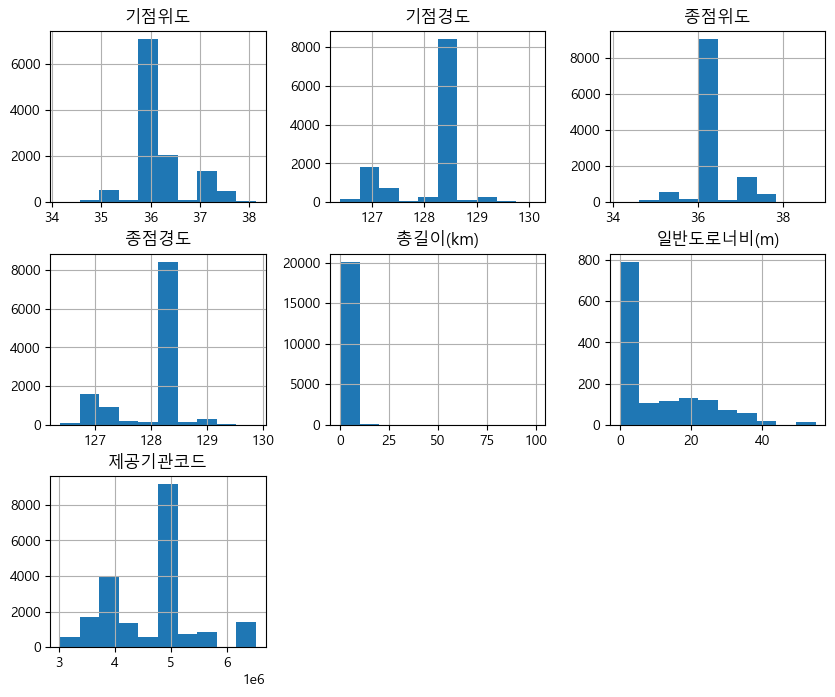

In [20]:
# 각 변수의 분포 확인
# 가로축은 값
# 세로축은 수치
df.hist(figsize=(10, 8))
plt.show()

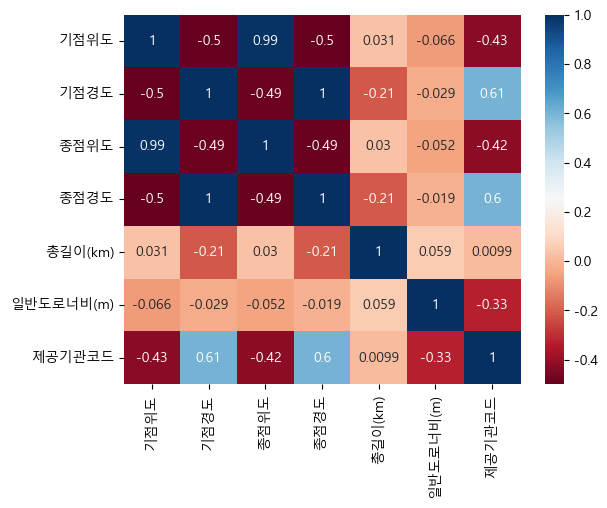

In [23]:
# 변수 간 상관관계 시각화
# 보고서에 제출할때 heatmap을 통해 상관관계표기 **필수
# 다중공산성 
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdBu')
plt.show()

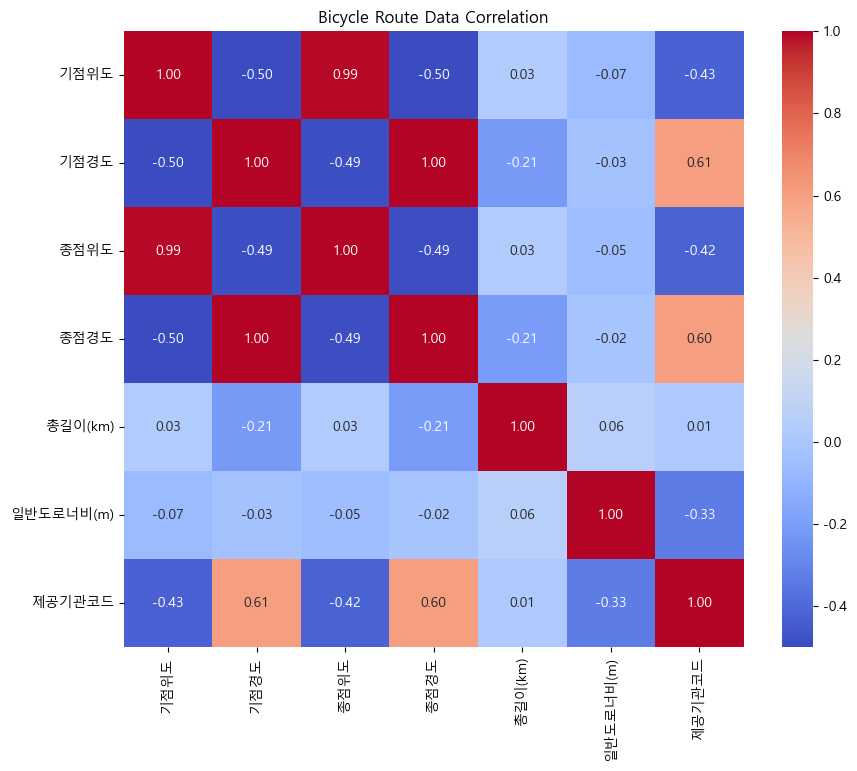

In [24]:
# 1. 숫자형 데이터가 있는 컬럼들만 리스트로 뽑기
# 예: '기점위도', '기점경도', '종점위도', '종점경도', '총길이(km)', '자전거도로너비(m)'
numeric_df = df.select_dtypes(include=['number'])

# 2. 선택된 데이터로 히트맵 그리기
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Bicycle Route Data Correlation")
plt.show()

In [22]:
# 결측치 확인
df.isnull().sum()

노선명               0
노선번호          17117
시도명               0
시군구명              0
기점도로명주소        3786
기점지번주소        15997
종점도로명주소        3764
종점지번주소        16002
기점위도           8423
기점경도           8423
종점위도           8452
종점경도           8452
주요경유지         17738
총길이(km)           0
일반도로너비(m)     18842
자전거도로너비(m)        0
자전거도로종류        3368
자전거도로고시유무      4341
관리기관명           339
관리기관전화번호       2288
데이터기준일자           0
제공기관코드            0
제공기관명             0
dtype: int64

회귀
분류

회귀 수치모델이다 리니어리그렉션 
독립변수 종속변수 
독립변수는 원인 종속ㅂㄴ수는 결과
y=ax + b
날씨와 아이스크림 판매량에서 날씨는 독립변수, y가 된다. 
아이스크림판매는 
판매량에 영향을 미친다

성적은 y
공부시간, 과외시간, 자습시간 등 x1,x2,x3가 된다 

단순선형회귀 x변수가 1개 여기서 x는 독립변수이다.
다중선형회귀 x1, x2, x3 등 여러개
다항선형회귀 데이터를 직선이 아니라 곡선으로 표현 


분류 바나나인지 사과인지 체리인지 

In [26]:
# 결측치 평균값으로 채우기
# 1. 숫자형 컬럼은 '평균값'으로 채우기
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# 2. 범주형(글자) 컬럼은 '최빈값(가장 많이 나온 값)'이나 '미상'으로 채우기
# 예: 자전거도로종류가 비어있으면 '알수없음'으로 채움
char_cols = df.select_dtypes(include=['object']).columns
df[char_cols] = df[char_cols].fillna('미상')

# 확인
print(df.isnull().sum())
df

노선명           0
노선번호          0
시도명           0
시군구명          0
기점도로명주소       0
기점지번주소        0
종점도로명주소       0
종점지번주소        0
기점위도          0
기점경도          0
종점위도          0
종점경도          0
주요경유지         0
총길이(km)       0
일반도로너비(m)     0
자전거도로너비(m)    0
자전거도로종류       0
자전거도로고시유무     0
관리기관명         0
관리기관전화번호      0
데이터기준일자       0
제공기관코드        0
제공기관명         0
dtype: int64


C:\Users\human-32\AppData\Local\Temp\ipykernel_9800\929038904.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  char_cols = df.select_dtypes(include=['object']).columns


,노선명,노선번호,시도명,시군구명,기점도로명주소,기점지번주소,종점도로명주소,종점지번주소,기점위도,기점경도,...,총길이(km),일반도로너비(m),자전거도로너비(m),자전거도로종류,자전거도로고시유무,관리기관명,관리기관전화번호,데이터기준일자,제공기관코드,제공기관명
0,사임당로(2),미상,경기도,파주시,미상,경기도 파주시 문산읍 선유리 668-3,미상,경기도 파주시 문산읍 선유리 434-9,36.262491,128.092992,...,2.32,10.401408,2,미상,미상,경기도 파주시청,031-940-4666,2025-12-22,4060000,경기도 파주시
1,사임당로(1),미상,경기도,파주시,미상,경기도 파주시 문산읍 선유리 1358,미상,경기도 파주시 문산읍 선유리 772-25,36.262491,128.092992,...,0.25,10.401408,1.5,미상,미상,경기도 파주시청,031-940-4666,2025-12-22,4060000,경기도 파주시
2,별하람로,미상,경기도,파주시,미상,경기도 파주시 와동동 802,미상,경기도 파주시 와동동 1664-390,36.262491,128.092992,...,0.83,10.401408,1.5,미상,미상,경기도 파주시청,031-940-4666,2025-12-22,4060000,경기도 파주시
3,법흥로,미상,경기도,파주시,미상,경기도 파주시 탄현면 법흥리 1759,미상,경기도 파주시 탄현면 법흥리 1678,36.262491,128.092992,...,1.28,10.401408,1.8,미상,미상,경기도 파주시청,031-940-4666,2025-12-22,4060000,경기도 파주시
4,범벅들길,미상,경기도,파주시,미상,경기도 파주시 다율동 1024,미상,경기도 파주시 다율동 794,36.262491,128.092992,...,1.08,10.401408,1.5,미상,미상,경기도 파주시청,031-940-4666,2025-12-22,4060000,경기도 파주시
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20257,계동로2L,미상,경상남도,김해시,미상,경상남도 김해시 대청동 334-4번지 일원,미상,경상남도 김해시 대청동 334-1번지 일원,36.262491,128.092992,...,0.32,10.401408,1.5,자전거전용차로,Y,경상남도 김해시청,055-330-3835,2025-12-16,5350000,경상남도 김해시
20258,계동로1R,미상,경상남도,김해시,미상,경상남도 김해시 관동동 산 150번지 일원,미상,경상남도 김해시 대청동 312-8번지 일원,36.262491,128.092992,...,2.46,10.401408,1.5,자전거보행자겸용도로,Y,경상남도 김해시청,055-330-3835,2025-12-16,5350000,경상남도 김해시
20259,계동로1L,미상,경상남도,김해시,미상,경상남도 김해시 대청동 316-3번지 일원,미상,경상남도 김해시 관동동 산 150번지 일원,36.262491,128.092992,...,2.50,10.401408,1.5,자전거보행자겸용도로,Y,경상남도 김해시청,055-330-3835,2025-12-16,5350000,경상남도 김해시
20260,서김해산단안길R,미상,경상남도,김해시,미상,경상남도 김해시 명법동 1122-6번지 일원,미상,경상남도 김해시 풍유동 1007번지 일원,36.262491,128.092992,...,1.31,10.401408,1.5,자전거보행자겸용도로,Y,경상남도 김해시청,055-330-3835,2025-12-16,5350000,경상남도 김해시


###Seaborn 함수

Index(['노선명', '노선번호', '시도명', '시군구명', '기점도로명주소', '기점지번주소', '종점도로명주소', '종점지번주소',
       '기점위도', '기점경도', '종점위도', '종점경도', '주요경유지', '총길이(km)', '일반도로너비(m)',
       '자전거도로너비(m)', '자전거도로종류', '자전거도로고시유무', '관리기관명', '관리기관전화번호', '데이터기준일자',
       '제공기관코드', '제공기관명'],
      dtype='object')


C:\Users\human-32\AppData\Local\Temp\ipykernel_14296\2253374733.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='자전거도로종류', y='자전거도로너비(m)', data=df, palette='muted')


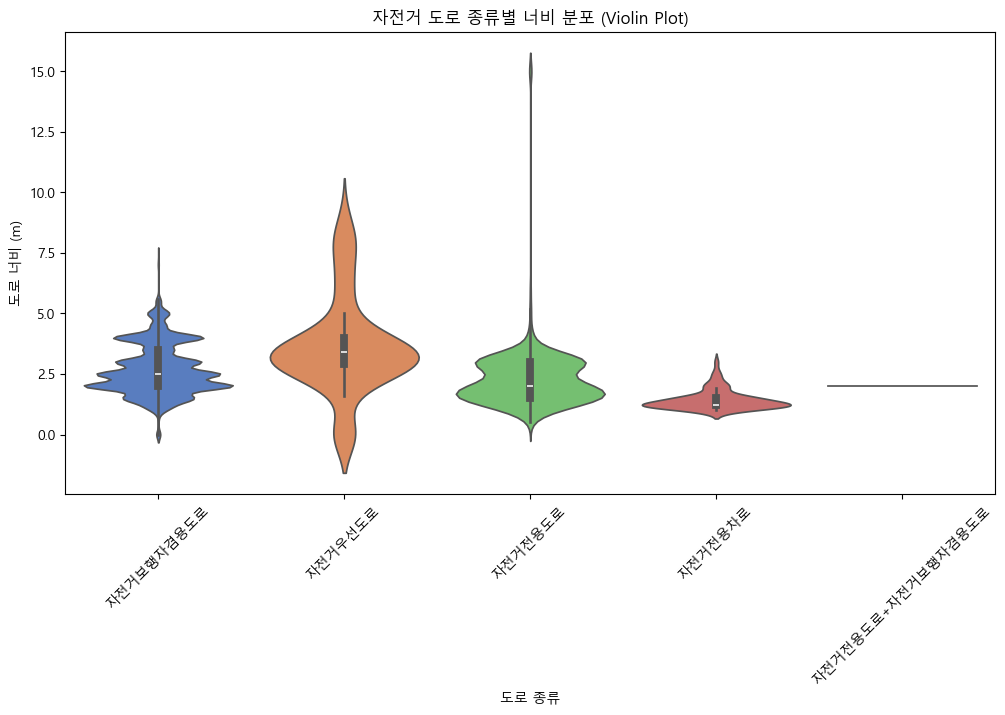

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 한글 폰트 설정 (Windows 기준)
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기
df = pd.read_csv('../raw_ml/bicycle_routes_clean.csv')

# 3. 데이터 확인 (실제 컬럼명이 맞는지 다시 확인)
print(df.columns)

# 4. Violinplot: 자전거도로종류에 따른 도로너비 분포 시각화
plt.figure(figsize=(12, 6))

# x와 y를 우리 데이터 컬럼명으로 변경
sns.violinplot(x='자전거도로종류', y='자전거도로너비(m)', data=df, palette='muted')

plt.title('자전거 도로 종류별 너비 분포 (Violin Plot)')
plt.xlabel('도로 종류')
plt.ylabel('도로 너비 (m)')

# x축 글자가 겹칠 경우 회전
plt.xticks(rotation=45)

plt.show()

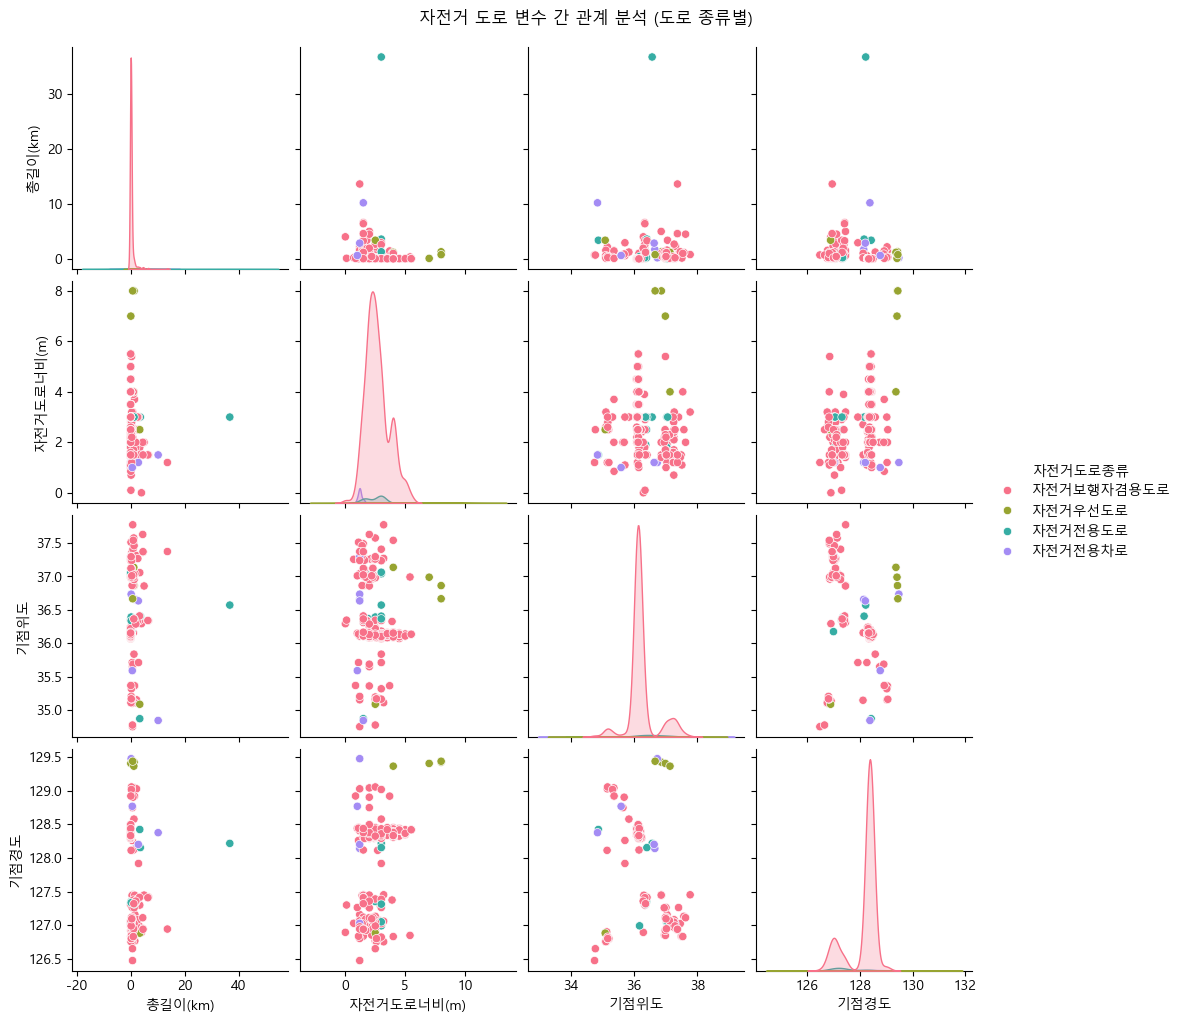

In [4]:
# Pairplot: 주요 변수들 간의 관계 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 설정 (이미 설정했다면 생략 가능)
plt.rc('font', family='Malgun Gothic')

# 2. 데이터가 너무 많으면 pairplot이 매우 느려지므로, 500개 정도만 샘플링해서 그리는 것을 추천합니다.
df_sample = df.sample(n=500, random_state=42) if len(df) > 500 else df

# 3. Pairplot 그리기
# vars: 보고 싶은 숫자형 컬럼들
# hue: 색깔로 구분해서 보고 싶은 범주형 컬럼 (예: 자전거도로종류)
sns.pairplot(df_sample, 
             vars=['총길이(km)', '자전거도로너비(m)', '기점위도', '기점경도'], 
             hue='자전거도로종류', 
             palette='husl')

plt.suptitle('자전거 도로 변수 간 관계 분석 (도로 종류별)', y=1.02)
plt.show()

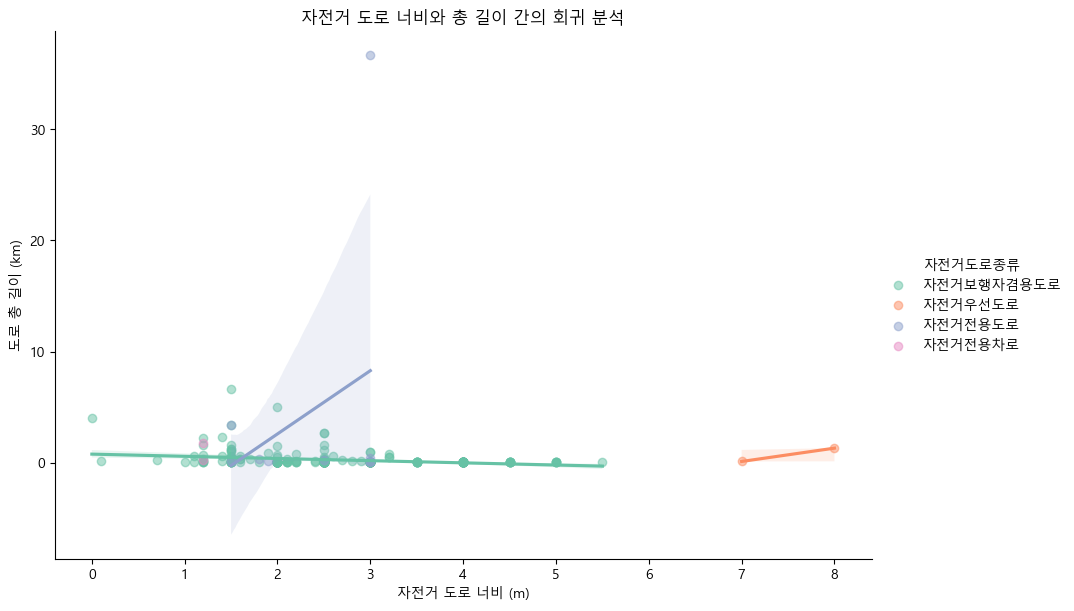

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')

# 2. 데이터 샘플링 (11,000건을 다 그리면 선이 너무 겹치므로 300개만 뽑아서 시각화)
df_sample = df.sample(n=300, random_state=42)

# 3. Lmplot 그리기
# x: 도로 너비, y: 도로 총 길이
# hue: 도로 종류별로 색깔과 회귀선을 다르게 표시
sns.lmplot(x='자전거도로너비(m)', y='총길이(km)', data=df_sample, 
           hue='자전거도로종류', palette='Set2', 
           height=6, aspect=1.5, scatter_kws={'alpha':0.5})

plt.title('자전거 도로 너비와 총 길이 간의 회귀 분석')
plt.xlabel('자전거 도로 너비 (m)')
plt.ylabel('도로 총 길이 (km)')

plt.show()

### 탐색적 데이터 분석(EDA)

In [ ]:
import os
import pandas as pd
from ydata_profiling import ProfileReport

# 1. 보고서를 저장할 폴더 생성 (없으면 자동 생성)
if not os.path.exists('report'):
    os.makedirs('report')
    print("report 폴더를 생성했습니다.")

# 2. 데이터 불러오기
file_path = '../raw_ml/bicycle_routes_clean.csv'
try:
    df = pd.read_csv(file_path)
    print("데이터 로드 성공!")
except Exception as e:
    print(f"파일 로드 실패: {e}")

# 3. YData Profiling 보고서 생성
# title을 프로젝트 명으로, 관측 모드(explorative) 활성화
profile = ProfileReport(df, title="K-Ride 자전거 도로 데이터 분석 보고서", explorative=True)

# 4. HTML 파일로 저장 (파일명 수정)
output_file = 'report/bicycle_data_profiling_report.html'
profile.to_file(output_file)

print(f"✅ 프로파일링 보고서가 생성되었습니다: {os.path.abspath(output_file)}")

데이터 로드 성공!


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 23/23 [00:01<00:00, 21.97it/s]
c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\ydata_profiling\visualisation\utils.py:73: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) Arial.
  plt.savefig(
c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\ydata_profiling\visualisation\utils.py:73: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) Arial.
  plt.savefig(
c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\ydata_profiling\visualisation\utils.py:73: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) Arial.
  plt.savefig(
c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\ydata_profiling\visualisation\utils.py:73: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  plt.savefig(
c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packa

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\ydata_profiling\visualisation\utils.py:73: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) Arial.
  plt.savefig(
c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\ydata_profiling\visualisation\utils.py:73: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) Arial.
  plt.savefig(
c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\ydata_profiling\visualisation\utils.py:73: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) Arial.
  plt.savefig(
c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\ydata_profiling\visualisation\utils.py:73: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) Arial.
  plt.savefig(
c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\.venv\lib\site-packages\ydata_profiling\visualisation\utils.py:73: 

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

✅ 프로파일링 보고서가 생성되었습니다: c:\Users\human-32\OneDrive\ドキュメント\yerinMin\humaneducation\kride-project\report\bicycle_data_profiling_report.html
